## Required Imports

In [11]:
import os
import tifffile
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from cuml.svm import SVC as cuSVC
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.utils import shuffle
import pandas as pd
import time
import cupy
print("cuML prerequisite 'cupy' found. GPU acceleration should be possible.")
import joblib
N_SPLITS = 5
NUM_EPOCHS = 10
BATCH_SIZE = 8
LEARNING_RATE = 0.00005
IS_GPU_AVAILABLE = True
RANDOM_STATE = 42
TEST_SET_SIZE = 0.05
np.random.seed(RANDOM_STATE)


cuML prerequisite 'cupy' found. GPU acceleration should be possible.


In [12]:
train_dir_path = "/kaggle/input/cloud-masking-dataset/content/train/data"
mask_dir_path = "/kaggle/input/cloud-masking-dataset/content/train/masks"
image_files = sorted([f for f in os.listdir(train_dir_path) if f.endswith((".tif", ".tiff"))])
mask_files = sorted([f for f in os.listdir(mask_dir_path) if f.endswith((".tif", ".tiff"))])


In [13]:
indices = np.arange(len(image_files))
train_val_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SET_SIZE,
    random_state=RANDOM_STATE,
    stratify=None
)
print(f"Total images: {len(indices)}")
print(f"Training + Validation indices: {len(train_val_idx)}")
print(f"Test indices: {len(test_idx)}")

Total images: 10573
Training + Validation indices: 10044
Test indices: 529


In [14]:
def preprocess_image_svm(image, mask):

    image = image.astype(np.float32) / 65536.0 
    mask = (mask > 0).astype(np.uint8)
    return image, mask


def extract_svm_features_and_labels(image_indices, img_dir, msk_dir, image_filenames, mask_filenames, n_samples_per_image=1000, random_state=None):
    all_features = []
    all_labels = []

    if random_state is not None:
        np.random.seed(random_state)

    print(f"Extracting features from {len(image_indices)} images...")
    for i, idx in enumerate(image_indices):
        if (i + 1) % 50 == 0:
             print(f"  Processing image {i+1}/{len(image_indices)}")

        img_path = os.path.join(img_dir, image_filenames[idx])
        mask_path = os.path.join(msk_dir, mask_filenames[idx])

        
        if not Path(img_path).exists() or not Path(mask_path).exists():
            print(f"Warning: Skipping index {idx}, file not found: {img_path} or {mask_path}")
            continue

        
        
        img = tifffile.imread(img_path)
        msk = tifffile.imread(mask_path)

        img_prep, msk_prep = preprocess_image_svm(img, msk)

        h, w, c = img_prep.shape
        img_reshaped = img_prep.reshape(-1, c)
        msk_reshaped = msk_prep.reshape(-1)

        num_pixels = h * w
        
        actual_samples = min(n_samples_per_image, num_pixels)
        if actual_samples == 0:
             print(f"Warning: Image {idx} has 0 pixels after reshape, skipping.")
             continue

        sample_indices = np.random.choice(num_pixels, size=actual_samples, replace=False)

        sampled_features = img_reshaped[sample_indices]
        sampled_labels = msk_reshaped[sample_indices]

        all_features.append(sampled_features)
        all_labels.append(sampled_labels)


    if not all_features:
        return np.array([]).reshape(0,c), np.array([]) 

    X = np.concatenate(all_features, axis=0)
    y = np.concatenate(all_labels, axis=0)
    
    X = X.astype(np.float32)
    y = y.astype(np.int32) 

    print(f"Extracted features shape: {X.shape}, Labels shape: {y.shape}")
    return X, y


In [15]:
num_train_images_to_sample = min(len(train_val_idx), 7500)
print(f"Sampling features from {num_train_images_to_sample} training images...")
train_sample_indices = np.random.choice(train_val_idx, size=num_train_images_to_sample, replace=False)

X_train_sampled, y_train_sampled = extract_svm_features_and_labels(
    train_sample_indices,
    train_dir_path,
    mask_dir_path,
    image_files,
    mask_files,
    n_samples_per_image=500,
    random_state=RANDOM_STATE
)


X_train_sampled, y_train_sampled = shuffle(X_train_sampled, y_train_sampled, random_state=RANDOM_STATE)

Sampling features from 7500 training images...
Extracting features from 7500 images...
  Processing image 50/7500
  Processing image 100/7500
  Processing image 150/7500
  Processing image 200/7500
  Processing image 250/7500
  Processing image 300/7500
  Processing image 350/7500
  Processing image 400/7500
  Processing image 450/7500
  Processing image 500/7500
  Processing image 550/7500
  Processing image 600/7500
  Processing image 650/7500
  Processing image 700/7500
  Processing image 750/7500
  Processing image 800/7500
  Processing image 850/7500
  Processing image 900/7500
  Processing image 950/7500
  Processing image 1000/7500
  Processing image 1050/7500
  Processing image 1100/7500
  Processing image 1150/7500
  Processing image 1200/7500
  Processing image 1250/7500
  Processing image 1300/7500
  Processing image 1350/7500
  Processing image 1400/7500
  Processing image 1450/7500
  Processing image 1500/7500
  Processing image 1550/7500
  Processing image 1600/7500
  Pro

In [16]:

print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sampled.astype(np.float32))
joblib.dump(scaler, 'svm_scaler.pkl')

Scaling features...


['svm_scaler.pkl']

In [17]:

print("Training SVM model using cuML (GPU)...")
svm_classifier = cuSVC(kernel='rbf', C=1.0, gamma='auto', probability=False, verbose=True)

start_time = time.time()

svm_classifier.fit(X_train_scaled, y_train_sampled.astype(np.int32))
end_time = time.time()
print(f"cuML SVM training complete. Time taken: {end_time - start_time:.2f} seconds.")

joblib.dump(svm_classifier, 'cuml_svm_cloud_masker.pkl')
scaler = joblib.load('svm_scaler.pkl')



Training SVM model using cuML (GPU)...
[2025-04-28 23:23:49.858] [CUML] [debug] Creating working set with 1024 elements
[2025-04-28 23:24:14.456] [CUML] [debug] Solver is not converging monotonically. This might be caused by insufficient normalization of the feature columns. In that case MinMaxScaler((0,1)) could help. Alternatively, for nonlinear kernels, you can try to increase the gamma parameter. To limit execution time, you can also adjust the number of iterations using the max_iter parameter.
[2025-04-28 23:24:39.710] [CUML] [debug] SMO iteration 500, diff 6.790367
[2025-04-28 23:25:34.735] [CUML] [debug] SMO iteration 1000, diff 5.944612
[2025-04-28 23:26:31.812] [CUML] [debug] SMO iteration 1500, diff 5.282189
[2025-04-28 23:27:33.488] [CUML] [debug] SMO iteration 2000, diff 5.427435
[2025-04-28 23:28:31.667] [CUML] [debug] SMO iteration 2500, diff 4.568850
[2025-04-28 23:29:30.440] [CUML] [debug] SMO iteration 3000, diff 5.014296
[2025-04-28 23:30:30.572] [CUML] [debug] SMO it

In [18]:
def predict_svm_mask(image_path, model, scaler):
    if not Path(image_path).exists():
        print(f"Error: Image file not found for prediction: {image_path}")
        return None

    img = tifffile.imread(image_path)
    
    img_prep, _ = preprocess_image_svm(img, np.zeros_like(img[:,:,0]))

    h, w, c = img_prep.shape
    if h * w == 0:
         print(f"Warning: Image {os.path.basename(image_path)} has zero size after processing.")
         return None
    img_reshaped = img_prep.reshape(-1, c)

    img_scaled = scaler.transform(img_reshaped.astype(np.float32))

    pixel_predictions = model.predict(img_scaled)

    predicted_mask = pixel_predictions.reshape(h, w).astype(np.uint8)
    if hasattr(predicted_mask, 'get'): 
         predicted_mask = predicted_mask.get()

    return predicted_mask


In [19]:
from tqdm import tqdm
def dice_coefficient_numpy(y_pred, y_true, epsilon=1e-6):
    y_pred = np.asarray(y_pred).astype(bool)
    y_true = np.asarray(y_true).astype(bool)

    y_pred_f = y_pred.flatten()
    y_true_f = y_true.flatten()

    intersection = np.sum(y_true_f & y_pred_f)
    sum_A = np.sum(y_true_f)
    sum_B = np.sum(y_pred_f)

    dice = (2. * intersection + epsilon) / (sum_A + sum_B + epsilon)
    return dice

print("\nEvaluating cuML SVM on Test Set...")
test_dice_scores = []
test_times = []

max_eval_images = 50

num_eval_images = min(max_eval_images, len(test_idx))

if num_eval_images == 0:
    print("No images available in the test set to evaluate.")
else:
    print(f"Evaluating on the first {num_eval_images} images of the test set...")
    
    eval_indices = test_idx[:num_eval_images]

    
    test_iterator = tqdm(eval_indices, desc=f"Evaluating Subset ({num_eval_images} images)", unit="image", leave=True)

    for idx in test_iterator:
        img_path = os.path.join(train_dir_path, image_files[idx])
        true_mask_path = os.path.join(mask_dir_path, mask_files[idx])

        if not Path(img_path).exists() or not Path(true_mask_path).exists():
            tqdm.write(f"Warning: Skipping test index {idx}, file not found.")
            continue

        pred_start_time = time.time()
        predicted_mask_svm = predict_svm_mask(img_path, svm_classifier, scaler)
        pred_end_time = time.time()
        test_times.append(pred_end_time - pred_start_time)

        if predicted_mask_svm is not None:
            true_mask = tifffile.imread(true_mask_path)
            dummy_shape_for_mask = (true_mask.shape[0], true_mask.shape[1], 1) if true_mask.ndim == 2 else (*true_mask.shape, 1)
            _, true_mask_prep = preprocess_image_svm(np.zeros(dummy_shape_for_mask, dtype=np.uint8), true_mask)

            if predicted_mask_svm.shape != true_mask_prep.shape:
                tqdm.write(f"Warning: Shape mismatch for index {idx}. Predicted: {predicted_mask_svm.shape}, True: {true_mask_prep.shape}. Skipping.")
                continue

            dice = dice_coefficient_numpy(predicted_mask_svm, true_mask_prep)
            test_dice_scores.append(dice)

            if test_dice_scores:
                 current_avg_dice = np.mean(test_dice_scores)
                 current_avg_time = np.mean(test_times)
                 test_iterator.set_postfix(avg_dice=f"{current_avg_dice:.4f}", avg_time=f"{current_avg_time:.4f}s", refresh=True)

        else:
            tqdm.write(f"Skipping evaluation for image index {idx} due to prediction error.")


    
    if test_dice_scores:
        avg_test_dice = np.mean(test_dice_scores)
        avg_test_time = np.mean(test_times) if test_times else 0
        
        print(f"\nFinal Average Dice Coefficient on {len(test_dice_scores)}/{num_eval_images} evaluated test images (cuML SVM): {avg_test_dice:.4f}")
        print(f"Final Average Prediction Time per Image (cuML SVM): {avg_test_time:.4f} seconds")
    elif num_eval_images > 0 : 
        print(f"\nNo test scores calculated for the evaluated subset of {num_eval_images} images (all failed or were skipped).")


Evaluating cuML SVM on Test Set...
Evaluating on the first 50 images of the test set...


Evaluating Subset (50 images): 100%|██████████| 50/50 [1:06:45<00:00, 80.12s/image, avg_dice=0.7077, avg_time=80.1032s]


Final Average Dice Coefficient on 50/50 evaluated test images (cuML SVM): 0.7077
Final Average Prediction Time per Image (cuML SVM): 80.1032 seconds



Visualizing some cuML SVM predictions on test set...


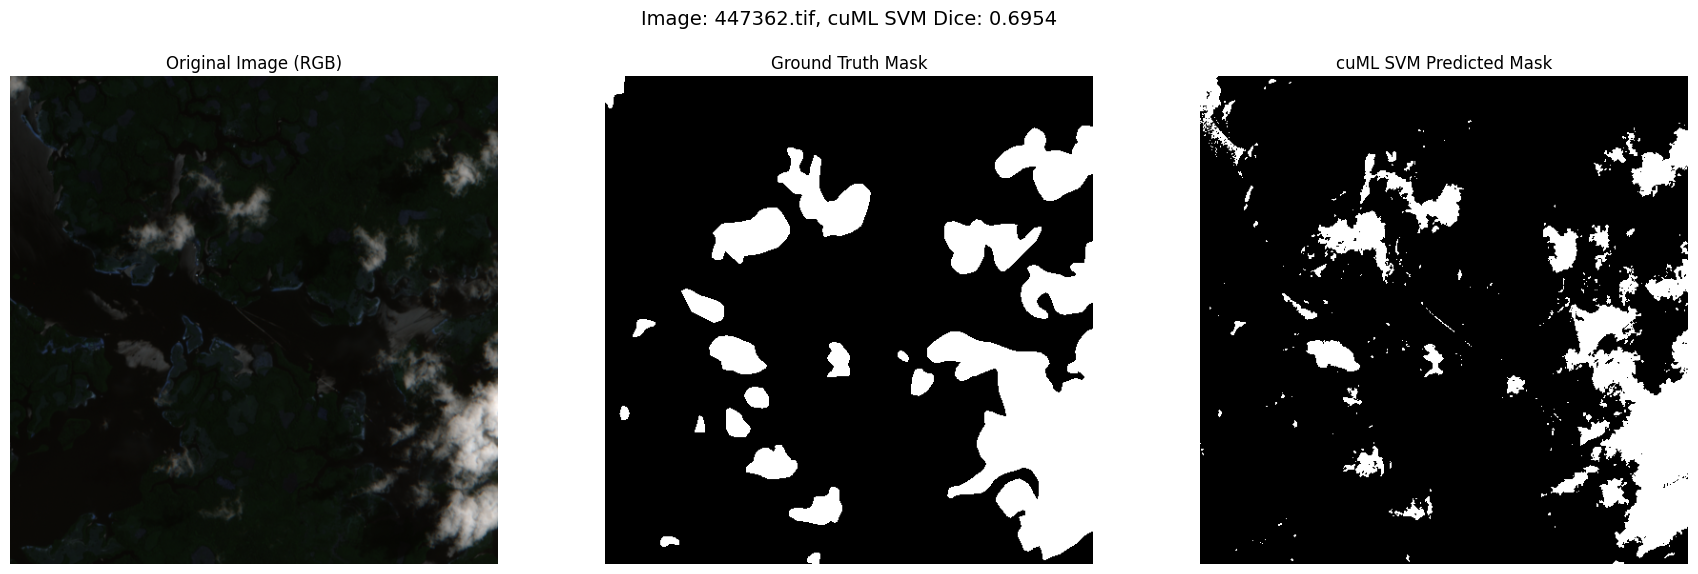

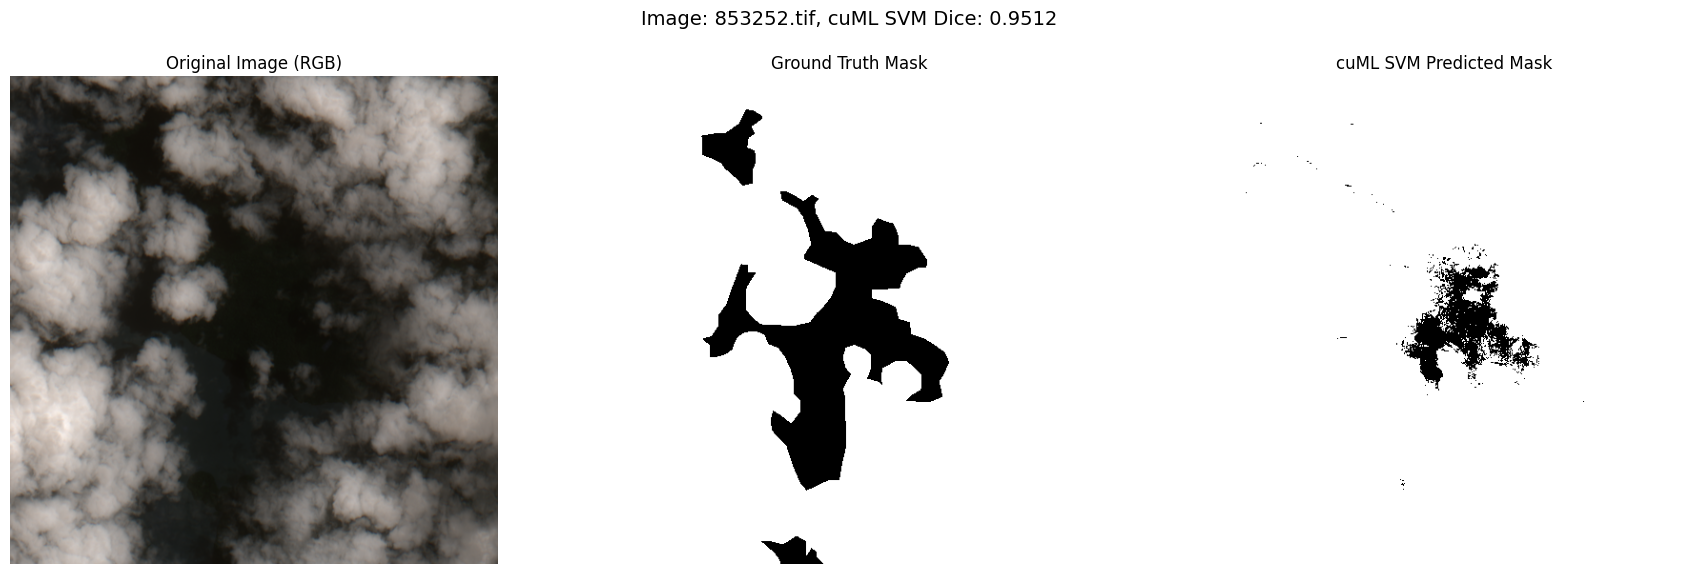

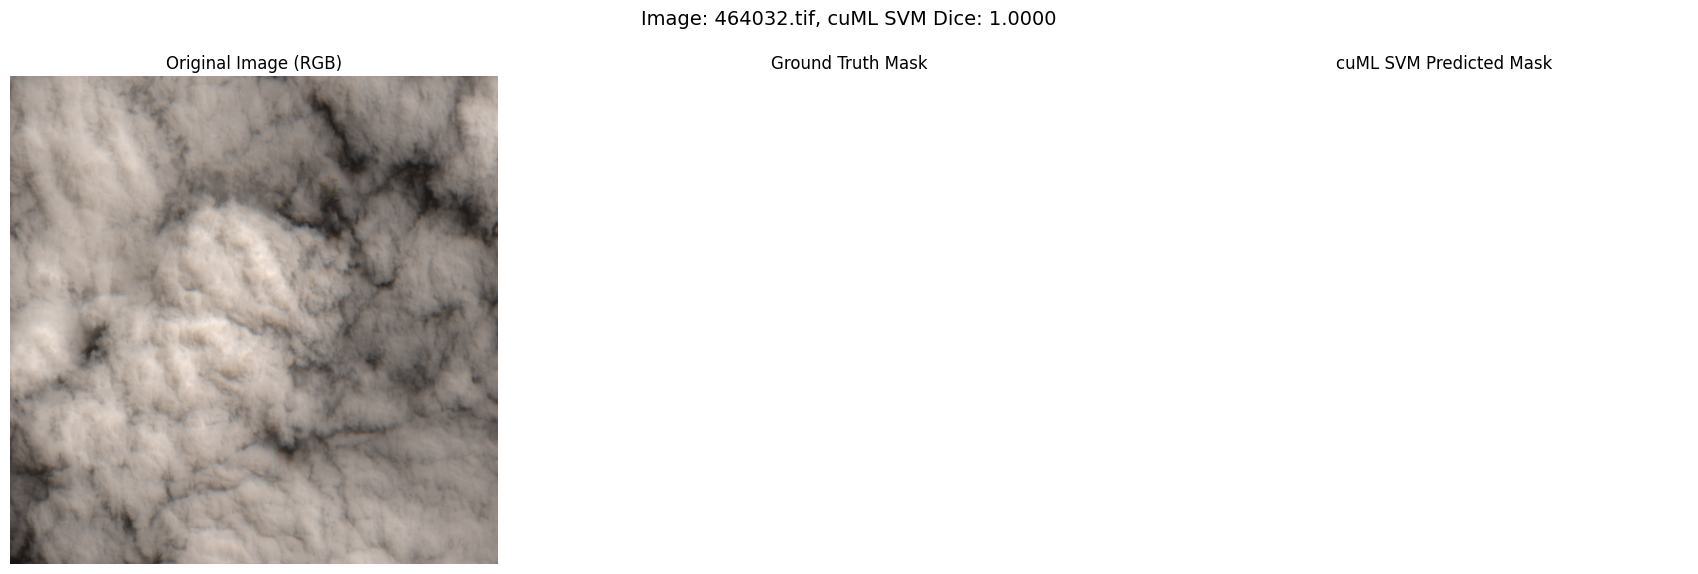

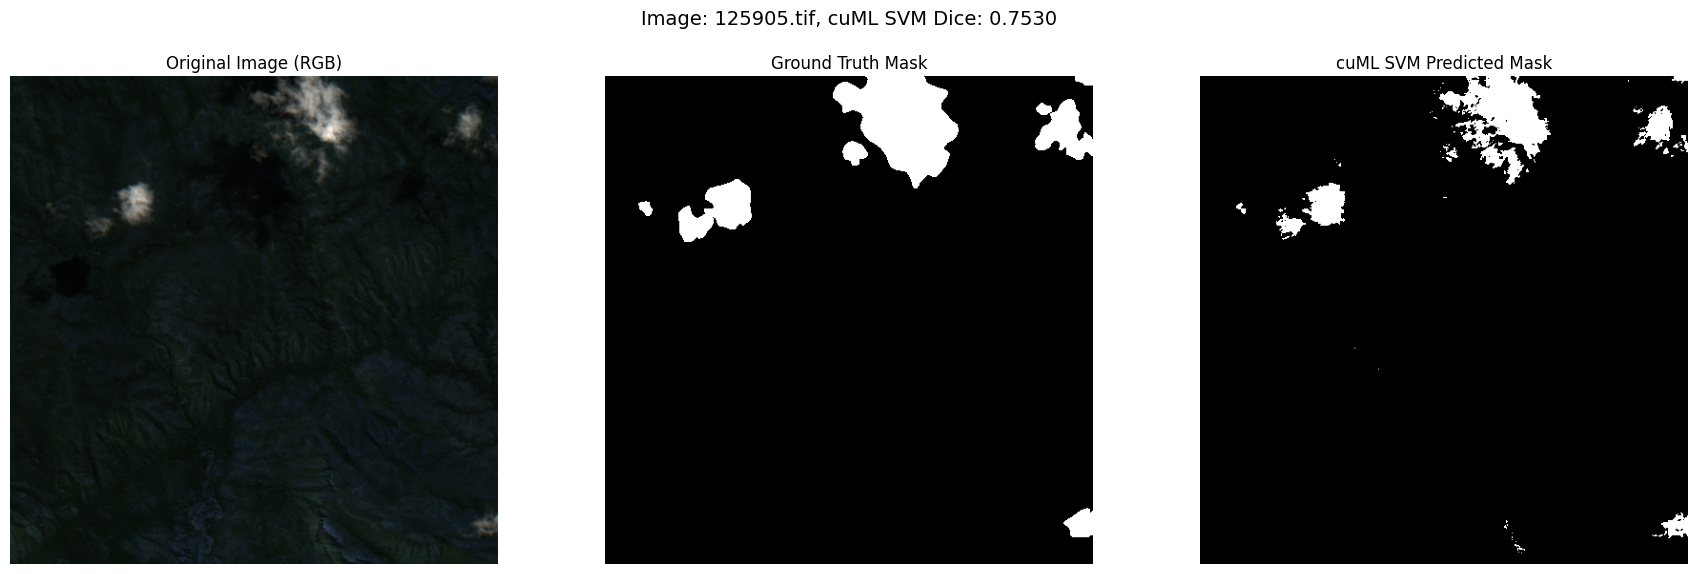

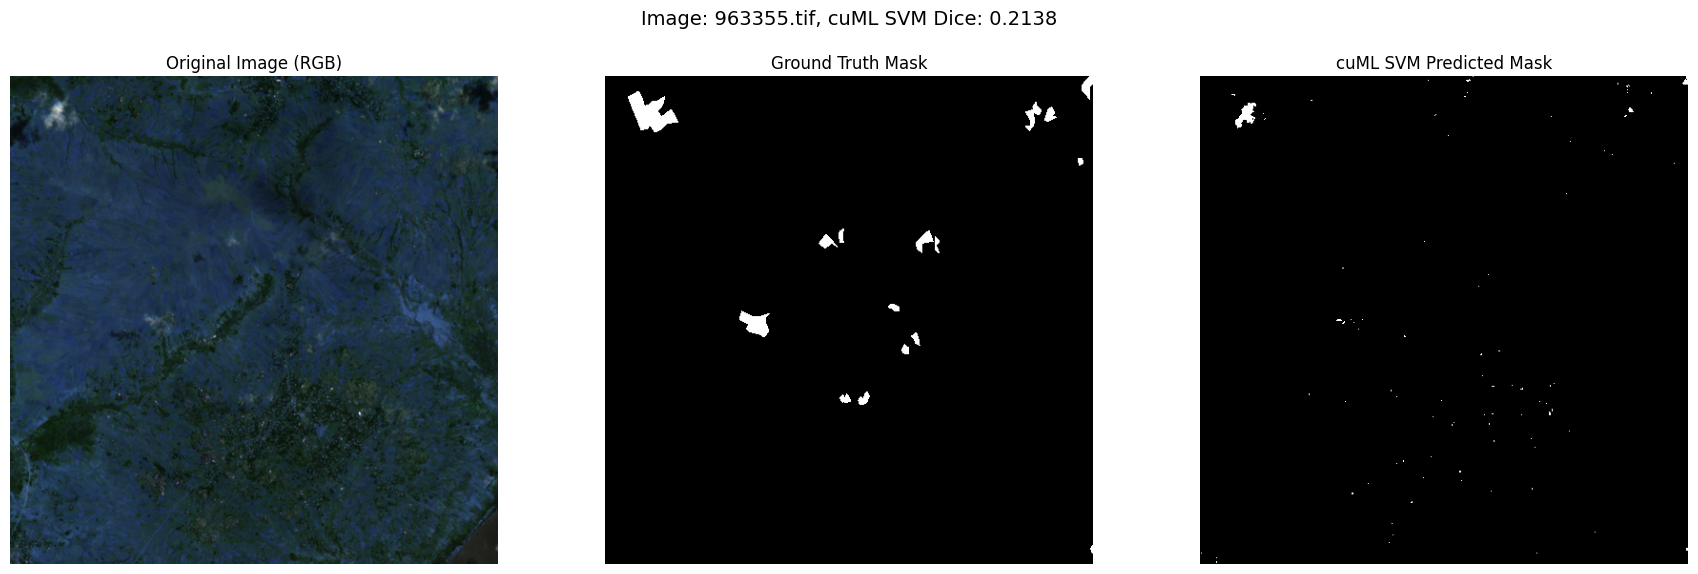

In [20]:
def visualize_svm_predictions(image_indices, model, scaler, img_dir, msk_dir, image_filenames, mask_filenames, num_to_show=20):
    count = 0
    indices_to_show = np.random.choice(image_indices, min(num_to_show, len(image_indices)), replace=False)

    for idx in indices_to_show:
        img_path = os.path.join(img_dir, image_filenames[idx])
        mask_path = os.path.join(msk_dir, mask_filenames[idx])

        if not Path(img_path).exists() or not Path(mask_path).exists():
             print(f"Warning: Skipping visualization for index {idx}, file not found.")
             continue

        img_orig = tifffile.imread(img_path)
        if img_orig.ndim >= 3 and img_orig.shape[2] >= 3:
             rgb_image = img_orig[:, :, :3]
        elif img_orig.ndim == 2: 
             rgb_image = np.stack([img_orig]*3, axis=-1)
        else:
             print(f"Warning: Cannot derive RGB from image shape {img_orig.shape} for index {idx}. Skipping visualization.")
             continue


        img_max = rgb_image.max()
        if img_max > 0:
             rgb_image = rgb_image.astype(np.float32) / float(img_max)
        rgb_image = np.clip(rgb_image, 0, 1)

        
        true_mask = tifffile.imread(mask_path)
        _, true_mask_prep = preprocess_image_svm(np.zeros_like(true_mask, shape=(*true_mask.shape, 1)), true_mask)

        
        predicted_mask = predict_svm_mask(img_path, model, scaler)

        if predicted_mask is not None:
            dice = dice_coefficient_numpy(predicted_mask, true_mask_prep)

            fig, axes = plt.subplots(1, 3, figsize=(18, 6))
            fig.suptitle(f"Image: {os.path.basename(img_path)}, cuML SVM Dice: {dice:.4f}", fontsize=14)

            axes[0].imshow(rgb_image)
            axes[0].set_title("Original Image (RGB)")
            axes[0].axis('off')

            axes[1].imshow(true_mask_prep, cmap='gray', vmin=0, vmax=1)
            axes[1].set_title("Ground Truth Mask")
            axes[1].axis('off')

            axes[2].imshow(predicted_mask, cmap='gray', vmin=0, vmax=1)
            axes[2].set_title("cuML SVM Predicted Mask")
            axes[2].axis('off')

            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()
            count += 1
        else:
             print(f"Skipping visualization for index {idx} due to prediction returning None.")


print("\nVisualizing some cuML SVM predictions on test set...")
visualize_svm_predictions(test_idx, svm_classifier, scaler, train_dir_path, mask_dir_path, image_files, mask_files, num_to_show=5)